# Comparing the resolution levels, how many cells within each group

Jaccard overlap between Metacells and ct+time 

In [1]:
#load the metacells and ct+time 
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

ctt_atac = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/ATAC/ctt_cell_id.csv")
sc_atac = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_ATAC.h5ad")

In [3]:
ctt_atac.head()

,cell_id,ctt
0,AAACAGCCACCTAAGC-1_1,epidermis_15somites
1,AAACAGCCAGGGAGGA-1_1,pronephros_15somites
2,AAACAGCCATAGACCC-1_1,hindbrain_15somites
3,AAACATGCAAACTCAT-1_1,spinal_cord_15somites
4,AAACATGCAAGGACCA-1_1,neural_optic2_15somites


In [12]:
#read in
sc_atac_cells = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/kernel_matrix_ATAC_cells.txt", header=None)

In [28]:
len(sc_atac_cells)

94562

In [27]:
len(sc_atac.obs_names)

1260

In [14]:
# read in /home/fgsasse_lrs_1/Downloads/kernel_matrix_ATAC(1).npy

sc = np.load("/home/fgsasse_lrs_1/Downloads/kernel_matrix_ATAC(1).npy", allow_pickle=True)

In [30]:
#add the cell-ids to the kernel matrix sc
sc_atac_cells.columns = ['cell_id']
sc_atac_cells['cell_id'] = sc_atac_cells.index

In [32]:
#get the columns of the sparse matrix sc


fn = "/home/fgsasse_lrs_1/Downloads/kernel_matrix_ATAC(1).npy"
mat_atac_sparse = np.load(fn, allow_pickle=True).item() # sparse array
mat_atac = mat_atac_sparse  # keep sparse to avoid MemoryError

data = mat_atac.data
print(f"Non-zero entries: {mat_atac.nnz}")
if np.any(data < 1):
    print(f"Max value (< 1) in the ATAC kernel matrix: {data[data < 1].max()}")
else:
    print("Max value (< 1) in the ATAC kernel matrix: NA")

if np.any(data > 0):
    print(f"Min value (> 0) in the ATAC kernel matrix: {data[data > 0].min()}")
else:
    print("Min value (> 0) in the ATAC kernel matrix: NA")
print(f"Shape of the ATAC kernel matrix: {mat_atac.shape}")
non_unit = data[data < 1]
print(f"Max value (< 1) in the ATAC kernel matrix: {non_unit.max() if non_unit.size else 'NA'}")
print(f"Min value (> 0) in the ATAC kernel matrix: {non_unit.min() if non_unit.size else 'NA'}")

fn = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/kernel_matrix_ATAC_cells.txt"
cells = pd.read_csv(fn, header=None)[0].tolist()
cells



Non-zero entries: 1969146
Max value (< 1) in the ATAC kernel matrix: 0.9586328186758669
Min value (> 0) in the ATAC kernel matrix: 0.020378026960141685
Shape of the ATAC kernel matrix: (94562, 94562)
Max value (< 1) in the ATAC kernel matrix: 0.9586328186758669
Min value (> 0) in the ATAC kernel matrix: 0.020378026960141685


['AAACAGCCACCTAAGC-1_1',
 'AAACAGCCAGGGAGGA-1_1',
 'AAACAGCCATAGACCC-1_1',
 'AAACATGCAAACTCAT-1_1',
 'AAACATGCAAGGACCA-1_1',
 'AAACATGCAAGGATTA-1_1',
 'AAACATGCACGTTACA-1_1',
 'AAACATGCAGGACCTT-1_1',
 'AAACATGCAGGCGATA-1_1',
 'AAACATGCAGTTTCTC-1_1',
 'AAACATGCATAGGCGA-1_1',
 'AAACCAACAGAGGGAG-1_1',
 'AAACCAACAGATTCAT-1_1',
 'AAACCAACAGCAGGTA-1_1',
 'AAACCAACATCACTTC-1_1',
 'AAACCAACATGTCAAT-1_1',
 'AAACCGAAGATAAAGC-1_1',
 'AAACCGAAGCACGATT-1_1',
 'AAACCGAAGCACTAAC-1_1',
 'AAACCGAAGCCTGAGC-1_1',
 'AAACCGAAGGATGATG-1_1',
 'AAACCGAAGGGTGAGT-1_1',
 'AAACCGAAGTCATCCC-1_1',
 'AAACCGCGTCAAGTAT-1_1',
 'AAACCGCGTCTTTATG-1_1',
 'AAACCGCGTTAGACCA-1_1',
 'AAACCGCGTTATCCGT-1_1',
 'AAACCGCGTTCAAGAT-1_1',
 'AAACCGGCAAAGCGGC-1_1',
 'AAACCGGCAAAGGTAC-1_1',
 'AAACCGGCAAATGCCC-1_1',
 'AAACCGGCAAGTGTTT-1_1',
 'AAACCGGCAATTGCGC-1_1',
 'AAACCGGCACATACTG-1_1',
 'AAACCGGCACCTGTAA-1_1',
 'AAACCGGCAGAATGAC-1_1',
 'AAACCGGCAGGCCATT-1_1',
 'AAACCGGCATCACTTC-1_1',
 'AAACGCGCAACGTGCT-1_1',
 'AAACGCGCAAGGTCCT-1_1',


In [ ]:
# Keep only cell_IDs with metacell or cell types_developmental lables
ctt_atac = ctt_atac[ctt_atac.obs['cell_ID'].isin(ctt_atac.obs['celltypes_developmental'])]
sc_atac = sc_atac[sc_atac.obs['cell_ID'].isin(sc_atac.obs['SEACell'])]

In [ ]:
sc_atac = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_ATAC.h5ad")

In [ ]:
# Jaccard overlap between all ATAC and RNA SEACells (based on shared single-cell barcodes)

# Keep only SEACells with at least 80 cells for better reliability of Jaccard estimates
atac_map = atac_map[atac_map["SEACell_atac_size"] >= 80]
rna_map = rna_map[rna_map["SEACell_rna_size"] >= 80]
print(f"SEACells with >=80 cells: {atac_map['SEACell_atac'].nunique()} ATAC SEACells, {rna_map['SEACell_rna'].nunique()} RNA SEACells")

# Keep only cells present in both modalities
joint = rna_map.join(atac_map, how="inner")
print(f"Shared cells: {joint.shape[0]}")

# Intersection sizes: |ATAC_i ∩ RNA_j|
intersections = pd.crosstab(joint["SEACell_atac"], joint["SEACell_rna"])

# Set sizes
atac_sizes = intersections.sum(axis=1).to_numpy()[:, None]  # |ATAC_i|
rna_sizes = intersections.sum(axis=0).to_numpy()[None, :]   # |RNA_j|

# Jaccard: |A∩B| / |A∪B|, with |A∪B| = |A| + |B| - |A∩B|
inter = intersections.to_numpy()
union = atac_sizes + rna_sizes - inter
jaccard = np.divide(inter, union, out=np.zeros_like(inter, dtype=float), where=union != 0)

# Make a DataFrame for better visualization
jaccard_df = pd.DataFrame(
    jaccard,
    index=intersections.index,
    columns=intersections.columns,
)

print(f"Jaccard matrix shape: {jaccard_df.shape}")
display(jaccard_df.iloc[:5, :5])


# Schematic of analysis

In [20]:
#read in the atac and rna data
import anndata 
pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")
pb_rna_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad")    

In [48]:
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/combined_gene_peak_assignments_10kb.csv")

In [53]:
#search for gene sox10 in the 10kb window
gene_peaks_10kb[gene_peaks_10kb['gene_id'] == 'shha']

,gene_id,assigned_peaks
13234,shha,"['7-40891789-40892839', '7-40888949-40890705',..."


In [6]:
pb_rna_ct_time.var_names

Index(['ptpn12', 'phtf2', 'phtf2.1', 'CU856344.1', 'si:zfos-932h1.3', 'mansc1',
       'lrp6', 'dusp16', 'crebl2', 'gpr19',
       ...
       'mt-nd4', 'NC-002333.16', 'NC-002333.15', 'NC-002333.8', 'mt-nd5',
       'mt-nd6', 'NC-002333.21', 'mt-cyb', 'NC-002333.22', 'NC-002333.11'],
      dtype='object', length=32057)

In [21]:
#filter the rna data to only include the gene sox10
pb_rna_ct_time = pb_rna_ct_time[:, pb_rna_ct_time.var_names.isin(["shha"])]
pb_rna_ct_time.X.shape

(196, 1)

In [22]:
#filter the atac data to only include the peaks corresponding to the index of the rna data
pb_atac_ct_time = pb_atac_ct_time[pb_rna_ct_time.obs_names, :]
pb_atac_ct_time.X.shape

(196, 640834)

In [24]:
pb_atac_ct_time.var_names


Index(['1-32-526', '1-2372-3057', '1-3427-4032', '1-4469-7268', '1-9541-9969',
       '1-11007-12962', '1-13276-13705', '1-14059-14260', '1-14625-15105',
       '1-15724-15934',
       ...
       '25-37489449-37490741', '25-37492035-37493157', '25-37493175-37493740',
       '25-37496420-37496948', '25-37497049-37497789', '25-37498106-37500090',
       '25-37500598-37500859', '25-37501104-37501839', 'MT-22-3567',
       'MT-13233-16532'],
      dtype='object', length=640834)

In [61]:
def _pearsonr(x, y):
    """Pearson r between two 1D arrays. Returns np.nan if either is constant."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xc = x - x.mean()
    yc = y - y.mean()
    denom = np.sqrt((xc ** 2).sum() * (yc ** 2).sum())
    if denom == 0:
        return np.nan
    return float(np.dot(xc, yc) / denom)


In [ ]:
import ast
import numpy as np
import pandas as pd


def _get_assigned_peaks(gene_peak_df, gene_name, peak_col, gene_id_col="gene_id"):
    """
    Look up the peaks assigned to `gene_name` in a gene x peak-assignment table.

    Looks up the gene by matching `gene_name` (case-insensitively) against the
    `gene_id_col` column if present; falls back to matching the DataFrame index
    otherwise. Handles the assigned-peaks column being stored as a real
    list/tuple/set/array, a stringified list (e.g. "['1-100-200', '1-300-400']"),
    or a plain delimited string (comma- or semicolon-separated).

    Returns
    -------
    list of str
        Peak names ('chrom-start-end') assigned to gene_name. Empty list if none.
    """
    row = None

    if gene_id_col in gene_peak_df.columns:
        mask = gene_peak_df[gene_id_col].astype(str).str.lower() == str(gene_name).lower()
        matches = gene_peak_df[mask]
        if len(matches) > 0:
            row = matches.iloc[0]

    if row is None:
        if gene_name in gene_peak_df.index:
            row = gene_peak_df.loc[gene_name]
        else:
            lower_lookup = {str(g).lower(): g for g in gene_peak_df.index}
            match = lower_lookup.get(str(gene_name).lower())
            if match is not None:
                row = gene_peak_df.loc[match]

    if row is None:
        close = []
        if gene_id_col in gene_peak_df.columns:
            close = gene_peak_df[gene_id_col][
                gene_peak_df[gene_id_col].astype(str).str.lower().str.contains(
                    str(gene_name).lower(), na=False
                )
            ].tolist()
        hint = f" Close matches in '{gene_id_col}': {close[:10]}." if close else ""
        raise ValueError(
            f"Gene '{gene_name}' not found (checked '{gene_id_col}' column and index).{hint}"
        )

    raw = row[peak_col]

    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return []

    if isinstance(raw, (list, tuple, set, np.ndarray, pd.Series)):
        peaks = [str(p).strip() for p in raw if str(p).strip()]
    elif isinstance(raw, str):
        stripped = raw.strip()
        if stripped.startswith("[") and stripped.endswith("]"):
            # Stringified list, e.g. "['1-100-200', '1-300-400']"
            parsed = ast.literal_eval(stripped)
            peaks = [str(p).strip() for p in parsed if str(p).strip()]
        else:
            sep = ";" if ";" in stripped else ","
            peaks = [p.strip().strip("'\"") for p in stripped.split(sep) if p.strip()]
    else:
        raise TypeError(
            f"Unrecognized type for assigned peaks in gene_peak_df['{peak_col}']: {type(raw)}"
        )

    return peaks


def plot_atac_expression_correlation(
    atac_df,
    rna_df,
    gene_name,
    tss_pos=None,
    tss_chrom=None,
    gene_peak_df=None,
    peak_col="assigned_peaks",
    gene_id_col="gene_id",
    selected_celltypes=None,
    n_celltypes=6,
    figsize=None,
    save_path=None,
    dpi=300,
    show_correlation_row=True,
    expression_unit="Expression",
):
    """
    Plot ATAC peak accessibility alongside gene expression per cell type,
    with an optional bottom row showing per-peak Pearson correlation with expression.

    Parameters
    ----------
    atac_df : pd.DataFrame
        Cell types as the index (rows), peaks as columns. Column names (peak/var_names)
        must be formatted as 'chrom-start-end' (e.g. '1-23-150'); 'start'/'end' coordinates
        and chromosome are parsed from these column names internally (the function
        transposes atac_df so peaks become rows for downstream plotting).
    rna_df : pd.DataFrame
        Cell types as the index (rows), genes as columns — e.g. straight from
        AnnData.to_df(). The function transposes internally so genes become rows.
        Cell-type names must overlap with those in atac_df (also cell types x peaks).
    gene_name : str
        Row index in rna_df to use as the expression signal.
    tss_pos : int or None
        Genomic position of the TSS. If provided, the x-axis shows distance from TSS
        and a vertical line marks the TSS. If None, absolute genomic midpoints are used.
    tss_chrom : str or int or None
        Chromosome the gene's TSS is on, used to restrict peaks to the same chromosome
        before any downstream analysis. Only used as a fallback when gene_peak_df is not
        provided. If None in that case, the chromosome is inferred as the majority
        chromosome among the peaks in atac_df (a warning is printed if peaks span more
        than one chromosome) — this fallback is a coarse approximation and should be
        avoided when a proper gene-to-peak assignment table is available.
    gene_peak_df : pd.DataFrame or None
        Gene x assigned-peaks table (e.g. for a 10kb window), indexed by gene name, with
        a column (see peak_col) listing the peak names assigned to that gene. When
        provided, atac_df is restricted to exactly these assigned peaks instead of using
        the tss_chrom/majority-vote fallback, which is the more correct behavior since it
        reflects the actual peak-to-gene assignment rather than a chromosome-wide filter.
    peak_col : str
        Column in gene_peak_df holding the assigned peaks for a gene. Values may be a
        list/tuple/set of peak names, a stringified list (e.g. "['1-100-200', ...]"),
        or a comma-/semicolon-separated string.
    gene_id_col : str
        Column in gene_peak_df holding the gene symbol/ID to match gene_name against.
        Falls back to matching gene_peak_df's index if this column isn't present.
    selected_celltypes : list of str or None
        Cell types to show. If None, n_celltypes are selected at random.
    n_celltypes : int
        Number of cell types to show when selected_celltypes is None.
    figsize : tuple or None
        Figure size. Auto-computed from n_celltypes if None.
    save_path : str or Path or None
        If given, saves the figure to this path.
    dpi : int
        Resolution when saving.
    show_correlation_row : bool
        If True, adds a bottom row showing per-peak Pearson r between ATAC
        accessibility (across selected cell types) and gene expression.
    expression_unit : str
        Label for the x-axis of the expression panel (e.g. 'log2 CPM', 'TPM', 'log1p CPM').
    """
    # --- Fix orientation: peaks are atac_df's COLUMNS (named 'chrom-start-end', e.g.
    # '1-23-150'), and cell types are the index. Transpose so peaks become rows, matching
    # what the rest of this function expects, then derive 'start'/'end' from the peak
    # names since there's no separate start/end column in this orientation.
    atac_df = atac_df.T
    atac_df.index.name = "peak"

    # rna_df has the same obs x var orientation issue (cell types as index, genes as
    # columns, e.g. straight from AnnData.to_df()). Transpose so genes become rows.
    rna_df = rna_df.T
    rna_df.index.name = "gene"

    split_names = atac_df.index.to_series().str.split("-", n=2, expand=True)
    if split_names.shape[1] < 3:
        raise ValueError(
            "atac_df column names (peaks) do not look like 'chrom-start-end' format "
            f"(e.g. '1-23-150'). Got values like: {atac_df.index[:5].tolist()}."
        )

    peak_chroms = split_names[0]
    peak_starts = pd.to_numeric(split_names[1], errors="coerce")
    peak_ends = pd.to_numeric(split_names[2], errors="coerce")

    if peak_starts.isna().any() or peak_ends.isna().any():
        raise ValueError(
            "Could not parse numeric start/end from peak names. "
            f"Got values like: {atac_df.index[:5].tolist()}."
        )

    atac_df = atac_df.copy()
    atac_df["start"] = peak_starts.values
    atac_df["end"] = peak_ends.values
    atac_df["_chrom"] = peak_chroms.values

    # Cell-type columns (everything except the coordinate/chrom helpers we just added)
    # may have come through as object dtype after the transpose; coerce to numeric.
    celltype_cols = [c for c in atac_df.columns if c not in ("start", "end", "_chrom")]
    atac_df[celltype_cols] = atac_df[celltype_cols].apply(pd.to_numeric, errors="coerce")

    if gene_peak_df is not None:
        # Preferred path: restrict to the peaks actually assigned to this gene.
        assigned_peaks = _get_assigned_peaks(gene_peak_df, gene_name, peak_col, gene_id_col)
        if not assigned_peaks:
            raise ValueError(
                f"No peaks assigned to gene '{gene_name}' in gene_peak_df['{peak_col}']."
            )

        n_before = len(atac_df)
        atac_df = atac_df[atac_df.index.isin(assigned_peaks)]
        n_removed = n_before - len(atac_df)
        if n_removed > 0:
            print(f"Restricted to {len(atac_df)} peak(s) assigned to '{gene_name}' "
                  f"(dropped {n_removed} peak(s) not in gene_peak_df['{peak_col}']).")

        if atac_df.empty:
            raise ValueError(
                f"None of the {len(assigned_peaks)} peak(s) assigned to '{gene_name}' "
                "were found in atac_df. Check that peak name formatting matches "
                "between gene_peak_df and atac_df."
            )

        # Sanity check: assigned peaks for one gene should be on a single chromosome.
        observed_chroms = atac_df["_chrom"].unique().tolist()
        if len(observed_chroms) > 1:
            print(
                f"Warning: assigned peaks for '{gene_name}' span multiple chromosomes "
                f"{observed_chroms}; this is unexpected for a single gene's window."
            )
        atac_df = atac_df.drop(columns="_chrom")

    else:
        if tss_chrom is None:
            chrom_counts = atac_df["_chrom"].value_counts()
            tss_chrom = chrom_counts.index[0]
            if len(chrom_counts) > 1:
                print(
                    f"Warning: peaks span multiple chromosomes {list(chrom_counts.index)}; "
                    f"defaulting to majority chromosome '{tss_chrom}'. "
                    f"Pass tss_chrom explicitly to override."
                )

        n_before = len(atac_df)
        atac_df = atac_df[atac_df["_chrom"] == str(tss_chrom)].drop(columns="_chrom")
        n_removed = n_before - len(atac_df)
        if n_removed > 0:
            print(f"Filtered out {n_removed} peak(s) not on chromosome '{tss_chrom}'.")

        if atac_df.empty:
            raise ValueError(f"No peaks remain on chromosome '{tss_chrom}' after filtering.")

    # Cell type columns: all numeric columns except the coordinate columns
    coord_cols = {"start", "end"}
    atac_celltypes = [
        c for c in atac_df.select_dtypes(include="number").columns
        if c not in coord_cols
    ]

    if selected_celltypes is None:
        rng = np.random.default_rng()
        selected_celltypes = list(
            rng.choice(atac_celltypes, size=min(n_celltypes, len(atac_celltypes)), replace=False)
        )

    common_celltypes = [ct for ct in selected_celltypes if ct in rna_df.columns]
    if not common_celltypes:
        raise ValueError(
            "No shared cell types between ATAC and RNA data. "
            "Check that selected_celltypes names match rna_df column names."
        )

    if gene_name not in rna_df.index:
        raise ValueError(f"Gene '{gene_name}' not found in rna_df index.")

    # --- Geometry ---
    atac_sorted = atac_df.sort_values("start").reset_index(drop=True)
    midpoints = (atac_sorted["start"].values + atac_sorted["end"].values) / 2
    bar_width = atac_sorted["end"].values - atac_sorted["start"].values

    if tss_pos is not None:
        x_positions = midpoints - tss_pos
        x_label = "Position relative to TSS"
    else:
        x_positions = midpoints
        x_label = "Genomic position"

    # x-axis ticks
    if tss_pos is not None:
        tick_step = max(500, round((x_positions.max() - x_positions.min()) / 10 / 500) * 500)
        first_tick = math.ceil(x_positions.min() / tick_step) * tick_step
        last_tick = math.floor(x_positions.max() / tick_step) * tick_step
        tick_offsets = list(range(int(first_tick), int(last_tick) + 1, tick_step))
        tick_labels = [
            "TSS" if off == 0 else (f"+{off // 1000}kb" if off > 0 else f"{off // 1000}kb")
            for off in tick_offsets
        ]
    else:
        tick_offsets = np.linspace(x_positions.min(), x_positions.max(), 6).astype(int).tolist()
        tick_labels = [str(v) for v in tick_offsets]

    x_margin = (x_positions.max() - x_positions.min()) * 0.05 + bar_width.mean() / 2
    x_lim = (x_positions.min() - x_margin, x_positions.max() + x_margin)

    # --- Expression values ---
    gene_expr = rna_df.loc[gene_name, common_celltypes].values.astype(float)
    expr_min, expr_max = gene_expr.min(), gene_expr.max()
    expr_range = expr_max - expr_min if expr_max != expr_min else 1.0
    expr_xlim = (expr_min - 0.05 * expr_range, expr_max + 0.2 * expr_range)

    # --- Shared ATAC y-scale ---
    all_atac = np.concatenate([atac_sorted[ct].values for ct in common_celltypes])
    y_min_g = all_atac.min()
    y_max_g = all_atac.max()
    y_range_g = y_max_g - y_min_g if y_max_g != y_min_g else 1.0
    y_lim_shared = (y_min_g - 0.05 * y_range_g, y_max_g + 0.15 * y_range_g)

    # --- Colors ---
    palette = [
        "#0173B2", "#DE8F05", "#029E73", "#CC78BC", "#CA9161",
        "#d55e00", "#56b4e9", "#009e73", "#0072b2", "#e69f00",
        "#aa4499", "#44aa99", "#332288", "#882255", "#117733",
    ]

    # --- Layout ---
    # A thin spacer row separates the cell type rows from the correlation row.
    n_show = len(common_celltypes)
    if show_correlation_row:
        n_rows = n_show + 2
        height_ratios = [1.0] * n_show + [0.25, 0.65]
        corr_row_idx = n_show + 1
    else:
        n_rows = n_show
        height_ratios = [1.0] * n_show
        corr_row_idx = None

    if figsize is None:
        figsize = (10, n_show * 1.5 + (1.3 if show_correlation_row else 0))

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_rows, 2,
        width_ratios=[3, 1],
        wspace=0.35,
        hspace=0.15,
        height_ratios=height_ratios,
    )

    show_atac_xlabels = not show_correlation_row

    for idx, celltype in enumerate(common_celltypes):
        is_last_atac = (idx == n_show - 1)

        # ATAC panel
        ax = fig.add_subplot(gs[idx, 0])
        values = atac_sorted[celltype].values
        ax.bar(
            x_positions, values, width=bar_width,
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="black", linewidth=0.5,
        )
        ax.text(
            -0.05, 0.5, celltype, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="center", ha="right",
        )
        if tss_pos is not None:
            ax.axvline(0, color="#2E2E2E", linewidth=1.5, linestyle="-", alpha=0.8, zorder=10)

        if idx == 0:
            ax.set_title("ATAC Accessibility", fontsize=12, fontweight="bold", pad=8)
            if tss_pos is not None:
                ax.text(
                    0, y_lim_shared[1], gene_name,
                    ha="center", va="bottom", fontsize=9, fontweight="bold", clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#2E2E2E", alpha=0.95, linewidth=1.2),
                )

        ax.set_ylim(y_lim_shared)
        ax.set_xlim(x_lim)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_xticks(tick_offsets)

        if is_last_atac and show_atac_xlabels:
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.set_xlabel(x_label, fontsize=10)
        else:
            ax.set_xticklabels(["" for _ in tick_offsets])
            ax.tick_params(axis="x", length=3)

        # Expression panel
        ax2 = fig.add_subplot(gs[idx, 1])
        ax2.barh(
            [0], [gene_expr[idx]],
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="none", height=0.08,
        )
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.spines["left"].set_visible(False)
        ax2.set_xlim(expr_xlim)
        ax2.set_ylim(-0.5, 0.5)
        ax2.set_yticks([])
        ax2.axvline(0, color="#aaaaaa", linewidth=0.5, zorder=0)

        if idx == 0:
            ax2.set_title(f"{gene_name} Expression", fontsize=10, fontweight="bold", pad=8)

        if is_last_atac and show_atac_xlabels:
            ax2.set_xlabel(expression_unit, fontsize=8)
            ax2.tick_params(axis="x", labelsize=7)
        else:
            ax2.set_xticks([])

    # --- Correlation row ---
    if show_correlation_row:
        r_vals = np.array([
            _pearsonr(
                atac_sorted.iloc[i][common_celltypes].values.astype(float),
                gene_expr,
            )
            for i in range(len(atac_sorted))
        ])

        ax_corr = fig.add_subplot(gs[corr_row_idx, 0])
        ax_corr.bar(
            x_positions, np.nan_to_num(r_vals), width=bar_width,
            color="#555555", alpha=0.85, edgecolor="black", linewidth=0.5,
        )
        ax_corr.axhline(0, color="#333333", linewidth=0.8)
        if tss_pos is not None:
            ax_corr.axvline(0, color="#2E2E2E", linewidth=1.5, linestyle="-", alpha=0.8, zorder=10)
        ax_corr.set_ylim(-1.1, 1.1)
        ax_corr.set_xlim(x_lim)
        ax_corr.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax_corr.set_yticklabels(["-1", "-0.5", "0", "0.5", "1"], fontsize=7)
        ax_corr.set_ylabel("Pearson r", fontsize=9)
        ax_corr.set_xticks(tick_offsets)
        ax_corr.set_xticklabels(tick_labels, fontsize=8)
        ax_corr.set_xlabel(x_label, fontsize=10)
        ax_corr.spines["top"].set_visible(False)
        ax_corr.spines["right"].set_visible(False)
        ax_corr.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax_corr.set_title("Peak-expression correlation (Pearson r across cell types)", fontsize=9, pad=4)

        ax_corr_r = fig.add_subplot(gs[corr_row_idx, 1])
        ax_corr_r.axis("off")

    plt.tight_layout(rect=[0.08, 0, 1.0, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")

    plt.show()
    return fig

Restricted to 7 peak(s) assigned to 'shha' (dropped 640827 peak(s) not in gene_peak_df['assigned_peaks']).


/tmp/ipykernel_2715343/3979768463.py:388: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0, 1.0, 1])


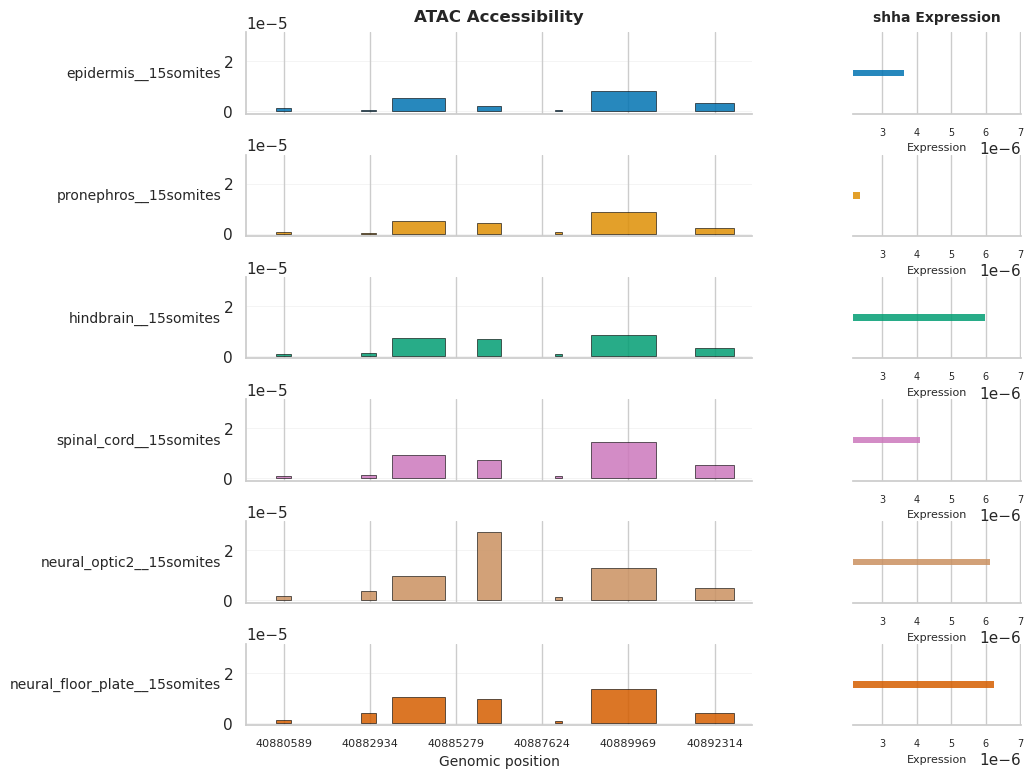

In [100]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  

fig = plot_atac_expression_correlation(
    atac_df=pb_atac_ct_time.to_df(),
    rna_df=pb_rna_ct_time.to_df(),
    gene_name="shha",
    tss_pos=None,
    gene_peak_df=gene_peaks_10kb,
    selected_celltypes= cts
)

In [79]:
atac_celltypes = set(pb_atac_ct_time.to_df().index)
rna_celltypes = set(pb_rna_ct_time.to_df().index)
print(sorted(atac_celltypes & rna_celltypes))

['NMPs__0somites', 'NMPs__10somites', 'NMPs__15somites', 'NMPs__5somites', 'PSM__0somites', 'PSM__10somites', 'PSM__15somites', 'PSM__20somites', 'PSM__5somites', 'differentiating_neurons__15somites', 'differentiating_neurons__20somites', 'differentiating_neurons__30somites', 'differentiating_neurons__5somites', 'endocrine_pancreas__0somites', 'endocrine_pancreas__10somites', 'endocrine_pancreas__15somites', 'endocrine_pancreas__20somites', 'endocrine_pancreas__5somites', 'endoderm__0somites', 'endoderm__10somites', 'endoderm__15somites', 'endoderm__20somites', 'endoderm__5somites', 'enteric_neurons__10somites', 'enteric_neurons__15somites', 'enteric_neurons__20somites', 'enteric_neurons__5somites', 'epidermis2__0somites', 'epidermis2__10somites', 'epidermis2__15somites', 'epidermis2__20somites', 'epidermis2__5somites', 'epidermis3__0somites', 'epidermis3__10somites', 'epidermis3__15somites', 'epidermis3__20somites', 'epidermis3__5somites', 'epidermis4__0somites', 'epidermis4__10somite

In [81]:
#find celltypes including ".._15somites" existing in both dataframes
cts = pb_atac_ct_time.obs_names[pb_atac_ct_time.obs_names.str.contains("15somites")].intersection(
    pb_rna_ct_time.obs_names[pb_rna_ct_time.obs_names.str.contains("15somites")]
).tolist()
cts = cts[:6]

In [ ]:
cts = ["lateral_plate_mesoderm__15somites", "neural_crest__15somites", "neural_plate__15somites", "paraxial_mesoderm__15somites", "neural_telencephalon__15somites", "somitic_mesoderm__15somites"]

In [28]:
def plot_atac_expression_correlation(
    atac_df,
    rna_df,
    gene_name,
    tss_pos=None,
    tss_chrom=None,
    selected_celltypes=None,
    n_celltypes=6,
    figsize=None,
    save_path=None,
    dpi=300,
    show_correlation_row=True,
    expression_unit="Expression",
):
    """
    Plot ATAC peak accessibility alongside gene expression per cell type,
    with an optional bottom row showing per-peak Pearson correlation with expression.

    Parameters
    ----------
    atac_df : pd.DataFrame
        One row per peak. Index (var_names) must be formatted as 'chrom-start-end'
        (e.g. '1-23-150'), and must have 'start' and 'end' columns (genomic coordinates).
        Cell-type columns are inferred as all numeric columns except 'start' and 'end'.
    rna_df : pd.DataFrame
        Gene expression table. Rows are genes (indexed by gene name), columns are cell types.
        Cell-type column names must overlap with those in atac_df.
    gene_name : str
        Row index in rna_df to use as the expression signal.
    tss_pos : int or None
        Genomic position of the TSS. If provided, the x-axis shows distance from TSS
        and a vertical line marks the TSS. If None, absolute genomic midpoints are used.
    tss_chrom : str or int or None
        Chromosome the gene's TSS is on, used to restrict peaks to the same chromosome
        before any downstream analysis. If None, the chromosome is inferred as the
        majority chromosome among the peaks in atac_df (a warning is printed if peaks
        span more than one chromosome).
    selected_celltypes : list of str or None
        Cell types to show. If None, n_celltypes are selected at random.
    n_celltypes : int
        Number of cell types to show when selected_celltypes is None.
    figsize : tuple or None
        Figure size. Auto-computed from n_celltypes if None.
    save_path : str or Path or None
        If given, saves the figure to this path.
    dpi : int
        Resolution when saving.
    show_correlation_row : bool
        If True, adds a bottom row showing per-peak Pearson r between ATAC
        accessibility (across selected cell types) and gene expression.
    expression_unit : str
        Label for the x-axis of the expression panel (e.g. 'log2 CPM', 'TPM', 'log1p CPM').
    """
    # --- Parse chromosome from peak names (var_names: 'chrom-start-end') and filter ---
    # e.g. '1-23-150' -> chrom='1', start=23, end=150. Only chrom is needed here since
    # 'start'/'end' columns already exist in atac_df.
    peak_chroms = atac_df.index.to_series().str.split("-", n=2, expand=True)[0]

    atac_df = atac_df.copy()
    atac_df["_chrom"] = peak_chroms.values

    if tss_chrom is None:
        chrom_counts = atac_df["_chrom"].value_counts()
        tss_chrom = chrom_counts.index[0]
        if len(chrom_counts) > 1:
            print(
                f"Warning: peaks span multiple chromosomes {list(chrom_counts.index)}; "
                f"defaulting to majority chromosome '{tss_chrom}'. "
                f"Pass tss_chrom explicitly to override."
            )

    n_before = len(atac_df)
    atac_df = atac_df[atac_df["_chrom"] == str(tss_chrom)].drop(columns="_chrom")
    n_removed = n_before - len(atac_df)
    if n_removed > 0:
        print(f"Filtered out {n_removed} peak(s) not on chromosome '{tss_chrom}'.")

    if atac_df.empty:
        raise ValueError(f"No peaks remain on chromosome '{tss_chrom}' after filtering.")

    # Cell type columns: all numeric columns except the coordinate columns
    coord_cols = {"start", "end"}
    atac_celltypes = [
        c for c in atac_df.select_dtypes(include="number").columns
        if c not in coord_cols
    ]

    if selected_celltypes is None:
        rng = np.random.default_rng()
        selected_celltypes = list(
            rng.choice(atac_celltypes, size=min(n_celltypes, len(atac_celltypes)), replace=False)
        )

    common_celltypes = [ct for ct in selected_celltypes if ct in rna_df.columns]
    if not common_celltypes:
        raise ValueError(
            "No shared cell types between ATAC and RNA data. "
            "Check that selected_celltypes names match rna_df column names."
        )

    if gene_name not in rna_df.index:
        raise ValueError(f"Gene '{gene_name}' not found in rna_df index.")

    # --- Geometry ---
    atac_sorted = atac_df.sort_values("start").reset_index(drop=True)
    midpoints = (atac_sorted["start"].values + atac_sorted["end"].values) / 2
    bar_width = atac_sorted["end"].values - atac_sorted["start"].values

    if tss_pos is not None:
        x_positions = midpoints - tss_pos
        x_label = "Position relative to TSS"
    else:
        x_positions = midpoints
        x_label = "Genomic position"

    # x-axis ticks
    if tss_pos is not None:
        tick_step = max(500, round((x_positions.max() - x_positions.min()) / 10 / 500) * 500)
        first_tick = math.ceil(x_positions.min() / tick_step) * tick_step
        last_tick = math.floor(x_positions.max() / tick_step) * tick_step
        tick_offsets = list(range(int(first_tick), int(last_tick) + 1, tick_step))
        tick_labels = [
            "TSS" if off == 0 else (f"+{off // 1000}kb" if off > 0 else f"{off // 1000}kb")
            for off in tick_offsets
        ]
    else:
        tick_offsets = np.linspace(x_positions.min(), x_positions.max(), 6).astype(int).tolist()
        tick_labels = [str(v) for v in tick_offsets]

    x_margin = (x_positions.max() - x_positions.min()) * 0.05 + bar_width.mean() / 2
    x_lim = (x_positions.min() - x_margin, x_positions.max() + x_margin)

    # --- Expression values ---
    gene_expr = rna_df.loc[gene_name, common_celltypes].values.astype(float)
    expr_min, expr_max = gene_expr.min(), gene_expr.max()
    expr_range = expr_max - expr_min if expr_max != expr_min else 1.0
    expr_xlim = (expr_min - 0.05 * expr_range, expr_max + 0.2 * expr_range)

    # --- Shared ATAC y-scale ---
    all_atac = np.concatenate([atac_sorted[ct].values for ct in common_celltypes])
    y_min_g = all_atac.min()
    y_max_g = all_atac.max()
    y_range_g = y_max_g - y_min_g if y_max_g != y_min_g else 1.0
    y_lim_shared = (y_min_g - 0.05 * y_range_g, y_max_g + 0.15 * y_range_g)

    # --- Colors ---
    palette = [
        "#0173B2", "#DE8F05", "#029E73", "#CC78BC", "#CA9161",
        "#d55e00", "#56b4e9", "#009e73", "#0072b2", "#e69f00",
        "#aa4499", "#44aa99", "#332288", "#882255", "#117733",
    ]

    # --- Layout ---
    # A thin spacer row separates the cell type rows from the correlation row.
    n_show = len(common_celltypes)
    if show_correlation_row:
        n_rows = n_show + 2
        height_ratios = [1.0] * n_show + [0.25, 0.65]
        corr_row_idx = n_show + 1
    else:
        n_rows = n_show
        height_ratios = [1.0] * n_show
        corr_row_idx = None

    if figsize is None:
        figsize = (10, n_show * 1.5 + (1.3 if show_correlation_row else 0))

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_rows, 2,
        width_ratios=[3, 1],
        wspace=0.35,
        hspace=0.15,
        height_ratios=height_ratios,
    )

    show_atac_xlabels = not show_correlation_row

    for idx, celltype in enumerate(common_celltypes):
        is_last_atac = (idx == n_show - 1)

        # ATAC panel
        ax = fig.add_subplot(gs[idx, 0])
        values = atac_sorted[celltype].values
        ax.bar(
            x_positions, values, width=bar_width,
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="black", linewidth=0.5,
        )
        ax.text(
            -0.05, 0.5, celltype, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="center", ha="right",
        )
        if tss_pos is not None:
            ax.axvline(0, color="#2E2E2E", linewidth=1.5, linestyle="-", alpha=0.8, zorder=10)

        if idx == 0:
            ax.set_title("ATAC Accessibility", fontsize=12, fontweight="bold", pad=8)
            if tss_pos is not None:
                ax.text(
                    0, y_lim_shared[1], gene_name,
                    ha="center", va="bottom", fontsize=9, fontweight="bold", clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#2E2E2E", alpha=0.95, linewidth=1.2),
                )

        ax.set_ylim(y_lim_shared)
        ax.set_xlim(x_lim)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_xticks(tick_offsets)

        if is_last_atac and show_atac_xlabels:
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.set_xlabel(x_label, fontsize=10)
        else:
            ax.set_xticklabels(["" for _ in tick_offsets])
            ax.tick_params(axis="x", length=3)

        # Expression panel
        ax2 = fig.add_subplot(gs[idx, 1])
        ax2.barh(
            [0], [gene_expr[idx]],
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="none", height=0.08,
        )
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.spines["left"].set_visible(False)
        ax2.set_xlim(expr_xlim)
        ax2.set_ylim(-0.5, 0.5)
        ax2.set_yticks([])
        ax2.axvline(0, color="#aaaaaa", linewidth=0.5, zorder=0)

        if idx == 0:
            ax2.set_title(f"{gene_name} Expression", fontsize=10, fontweight="bold", pad=8)

        if is_last_atac and show_atac_xlabels:
            ax2.set_xlabel(expression_unit, fontsize=8)
            ax2.tick_params(axis="x", labelsize=7)
        else:
            ax2.set_xticks([])

    # --- Correlation row ---
    if show_correlation_row:
        r_vals = np.array([
            _pearsonr(
                atac_sorted.iloc[i][common_celltypes].values.astype(float),
                gene_expr,
            )
            for i in range(len(atac_sorted))
        ])

        ax_corr = fig.add_subplot(gs[corr_row_idx, 0])
        ax_corr.bar(
            x_positions, np.nan_to_num(r_vals), width=bar_width,
            color="#555555", alpha=0.85, edgecolor="black", linewidth=0.5,
        )
        ax_corr.axhline(0, color="#333333", linewidth=0.8)
        if tss_pos is not None:
            ax_corr.axvline(0, color="#2E2E2E", linewidth=1.5, linestyle="-", alpha=0.8, zorder=10)
        ax_corr.set_ylim(-1.1, 1.1)
        ax_corr.set_xlim(x_lim)
        ax_corr.set_yticks([-1, -0.5, 0, 0.5, 1])
        ax_corr.set_yticklabels(["-1", "-0.5", "0", "0.5", "1"], fontsize=7)
        ax_corr.set_ylabel("Pearson r", fontsize=9)
        ax_corr.set_xticks(tick_offsets)
        ax_corr.set_xticklabels(tick_labels, fontsize=8)
        ax_corr.set_xlabel(x_label, fontsize=10)
        ax_corr.spines["top"].set_visible(False)
        ax_corr.spines["right"].set_visible(False)
        ax_corr.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax_corr.set_title("Peak-expression correlation (Pearson r across cell types)", fontsize=9, pad=4)

        ax_corr_r = fig.add_subplot(gs[corr_row_idx, 1])
        ax_corr_r.axis("off")

    plt.tight_layout(rect=[0.08, 0, 1.0, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")

    plt.show()
    return fig

In [42]:
import numpy as np
import pandas as pd
plot_atac_expression_correlation(
    atac_df=pb_atac_ct_time.to_df(),
    rna_df=pb_rna_ct_time.to_df(),
    gene_name="shha",
    tss_pos=None,
    tss_chrom= None,
    selected_celltypes=None,
    n_celltypes=6,
    figsize=(10, 8),
    save_path=None,
    dpi=300,
    show_correlation_row=True,
    expression_unit="Expression",
)

Filtered out 605560 peak(s) not on chromosome '7'.


ValueError: No shared cell types between ATAC and RNA data. Check that selected_celltypes names match rna_df column names.

In [99]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns


def _get_assigned_peaks(gene_peak_df, gene_name, peak_col, gene_id_col="gene_id"):
    """
    Look up the peaks assigned to `gene_name` in a gene x peak-assignment table.

    Looks up the gene by matching `gene_name` (case-insensitively) against the
    `gene_id_col` column if present; falls back to matching the DataFrame index
    otherwise. Handles the assigned-peaks column being stored as a real
    list/tuple/set/array, a stringified list (e.g. "['1-100-200', '1-300-400']"),
    or a plain delimited string (comma- or semicolon-separated).

    Returns
    -------
    list of str
        Peak names ('chrom-start-end') assigned to gene_name. Empty list if none.
    """
    row = None

    if gene_id_col in gene_peak_df.columns:
        mask = gene_peak_df[gene_id_col].astype(str).str.lower() == str(gene_name).lower()
        matches = gene_peak_df[mask]
        if len(matches) > 0:
            row = matches.iloc[0]

    if row is None:
        if gene_name in gene_peak_df.index:
            row = gene_peak_df.loc[gene_name]
        else:
            lower_lookup = {str(g).lower(): g for g in gene_peak_df.index}
            match = lower_lookup.get(str(gene_name).lower())
            if match is not None:
                row = gene_peak_df.loc[match]

    if row is None:
        close = []
        if gene_id_col in gene_peak_df.columns:
            close = gene_peak_df[gene_id_col][
                gene_peak_df[gene_id_col].astype(str).str.lower().str.contains(
                    str(gene_name).lower(), na=False
                )
            ].tolist()
        hint = f" Close matches in '{gene_id_col}': {close[:10]}." if close else ""
        raise ValueError(
            f"Gene '{gene_name}' not found (checked '{gene_id_col}' column and index).{hint}"
        )

    raw = row[peak_col]

    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return []

    if isinstance(raw, (list, tuple, set, np.ndarray, pd.Series)):
        peaks = [str(p).strip() for p in raw if str(p).strip()]
    elif isinstance(raw, str):
        stripped = raw.strip()
        if stripped.startswith("[") and stripped.endswith("]"):
            # Stringified list, e.g. "['1-100-200', '1-300-400']"
            parsed = ast.literal_eval(stripped)
            peaks = [str(p).strip() for p in parsed if str(p).strip()]
        else:
            sep = ";" if ";" in stripped else ","
            peaks = [p.strip().strip("'\"") for p in stripped.split(sep) if p.strip()]
    else:
        raise TypeError(
            f"Unrecognized type for assigned peaks in gene_peak_df['{peak_col}']: {type(raw)}"
        )

    return peaks


def plot_atac_expression_correlation(
    atac_df,
    rna_df,
    gene_name,
    tss_pos=None,
    tss_chrom=None,
    gene_peak_df=None,
    peak_col="assigned_peaks",
    gene_id_col="gene_id",
    selected_celltypes=None,
    n_celltypes=6,
    figsize=None,
    save_path=None,
    dpi=300,
    expression_unit="Expression",
):
    """
    Plot ATAC peak accessibility alongside gene expression per cell type, in seaborn
    style.

    Parameters
    ----------
    atac_df : pd.DataFrame
        Cell types as the index (rows), peaks as columns. Column names (peak/var_names)
        must be formatted as 'chrom-start-end' (e.g. '1-23-150'); 'start'/'end' coordinates
        and chromosome are parsed from these column names internally (the function
        transposes atac_df so peaks become rows for downstream plotting).
    rna_df : pd.DataFrame
        Cell types as the index (rows), genes as columns — e.g. straight from
        AnnData.to_df(). The function transposes internally so genes become rows.
        Cell-type names must overlap with those in atac_df (also cell types x peaks).
    gene_name : str
        Row index in rna_df to use as the expression signal.
    tss_pos : int or None
        Genomic position of the TSS. If provided, the x-axis shows distance from TSS
        and a vertical line marks the TSS. If None, absolute genomic midpoints are used.
    tss_chrom : str or int or None
        Chromosome the gene's TSS is on, used to restrict peaks to the same chromosome
        before any downstream analysis. Only used as a fallback when gene_peak_df is not
        provided. If None in that case, the chromosome is inferred as the majority
        chromosome among the peaks in atac_df (a warning is printed if peaks span more
        than one chromosome) — this fallback is a coarse approximation and should be
        avoided when a proper gene-to-peak assignment table is available.
    gene_peak_df : pd.DataFrame or None
        Gene x assigned-peaks table (e.g. for a 10kb window), indexed by gene name, with
        a column (see peak_col) listing the peak names assigned to that gene. When
        provided, atac_df is restricted to exactly these assigned peaks instead of using
        the tss_chrom/majority-vote fallback, which is the more correct behavior since it
        reflects the actual peak-to-gene assignment rather than a chromosome-wide filter.
    peak_col : str
        Column in gene_peak_df holding the assigned peaks for a gene. Values may be a
        list/tuple/set of peak names, a stringified list (e.g. "['1-100-200', ...]"),
        or a comma-/semicolon-separated string.
    gene_id_col : str
        Column in gene_peak_df holding the gene symbol/ID to match gene_name against.
        Falls back to matching gene_peak_df's index if this column isn't present.
    selected_celltypes : list of str or None
        Cell types to show. If None, n_celltypes are selected at random.
    n_celltypes : int
        Number of cell types to show when selected_celltypes is None.
    figsize : tuple or None
        Figure size. Auto-computed from n_celltypes if None.
    save_path : str or Path or None
        If given, saves the figure to this path.
    dpi : int
        Resolution when saving.
    expression_unit : str
        Label for the x-axis of the expression panel (e.g. 'log2 CPM', 'TPM', 'log1p CPM').
    """
    # --- Fix orientation: peaks are atac_df's COLUMNS (named 'chrom-start-end', e.g.
    # '1-23-150'), and cell types are the index. Transpose so peaks become rows, matching
    # what the rest of this function expects, then derive 'start'/'end' from the peak
    # names since there's no separate start/end column in this orientation.
    atac_df = atac_df.T
    atac_df.index.name = "peak"

    # rna_df has the same obs x var orientation issue (cell types as index, genes as
    # columns, e.g. straight from AnnData.to_df()). Transpose so genes become rows.
    rna_df = rna_df.T
    rna_df.index.name = "gene"

    split_names = atac_df.index.to_series().str.split("-", n=2, expand=True)
    if split_names.shape[1] < 3:
        raise ValueError(
            "atac_df column names (peaks) do not look like 'chrom-start-end' format "
            f"(e.g. '1-23-150'). Got values like: {atac_df.index[:5].tolist()}."
        )

    peak_chroms = split_names[0]
    peak_starts = pd.to_numeric(split_names[1], errors="coerce")
    peak_ends = pd.to_numeric(split_names[2], errors="coerce")

    if peak_starts.isna().any() or peak_ends.isna().any():
        raise ValueError(
            "Could not parse numeric start/end from peak names. "
            f"Got values like: {atac_df.index[:5].tolist()}."
        )

    atac_df = atac_df.copy()
    atac_df["start"] = peak_starts.values
    atac_df["end"] = peak_ends.values
    atac_df["_chrom"] = peak_chroms.values

    # Cell-type columns (everything except the coordinate/chrom helpers we just added)
    # may have come through as object dtype after the transpose; coerce to numeric.
    celltype_cols = [c for c in atac_df.columns if c not in ("start", "end", "_chrom")]
    atac_df[celltype_cols] = atac_df[celltype_cols].apply(pd.to_numeric, errors="coerce")

    if gene_peak_df is not None:
        # Preferred path: restrict to the peaks actually assigned to this gene.
        assigned_peaks = _get_assigned_peaks(gene_peak_df, gene_name, peak_col, gene_id_col)
        if not assigned_peaks:
            raise ValueError(
                f"No peaks assigned to gene '{gene_name}' in gene_peak_df['{peak_col}']."
            )

        n_before = len(atac_df)
        atac_df = atac_df[atac_df.index.isin(assigned_peaks)]
        n_removed = n_before - len(atac_df)
        if n_removed > 0:
            print(f"Restricted to {len(atac_df)} peak(s) assigned to '{gene_name}' "
                  f"(dropped {n_removed} peak(s) not in gene_peak_df['{peak_col}']).")

        if atac_df.empty:
            raise ValueError(
                f"None of the {len(assigned_peaks)} peak(s) assigned to '{gene_name}' "
                "were found in atac_df. Check that peak name formatting matches "
                "between gene_peak_df and atac_df."
            )

        # Sanity check: assigned peaks for one gene should be on a single chromosome.
        observed_chroms = atac_df["_chrom"].unique().tolist()
        if len(observed_chroms) > 1:
            print(
                f"Warning: assigned peaks for '{gene_name}' span multiple chromosomes "
                f"{observed_chroms}; this is unexpected for a single gene's window."
            )
        atac_df = atac_df.drop(columns="_chrom")

    else:
        if tss_chrom is None:
            chrom_counts = atac_df["_chrom"].value_counts()
            tss_chrom = chrom_counts.index[0]
            if len(chrom_counts) > 1:
                print(
                    f"Warning: peaks span multiple chromosomes {list(chrom_counts.index)}; "
                    f"defaulting to majority chromosome '{tss_chrom}'. "
                    f"Pass tss_chrom explicitly to override."
                )

        n_before = len(atac_df)
        atac_df = atac_df[atac_df["_chrom"] == str(tss_chrom)].drop(columns="_chrom")
        n_removed = n_before - len(atac_df)
        if n_removed > 0:
            print(f"Filtered out {n_removed} peak(s) not on chromosome '{tss_chrom}'.")

        if atac_df.empty:
            raise ValueError(f"No peaks remain on chromosome '{tss_chrom}' after filtering.")

    # Cell type columns: all numeric columns except the coordinate columns
    coord_cols = {"start", "end"}
    atac_celltypes = [
        c for c in atac_df.select_dtypes(include="number").columns
        if c not in coord_cols
    ]

    if selected_celltypes is None:
        rng = np.random.default_rng()
        selected_celltypes = list(
            rng.choice(atac_celltypes, size=min(n_celltypes, len(atac_celltypes)), replace=False)
        )

    common_celltypes = [ct for ct in selected_celltypes if ct in rna_df.columns]
    if not common_celltypes:
        raise ValueError(
            "No shared cell types between ATAC and RNA data. "
            "Check that selected_celltypes names match rna_df column names."
        )

    if gene_name not in rna_df.index:
        raise ValueError(f"Gene '{gene_name}' not found in rna_df index.")

    # --- Geometry ---
    atac_sorted = atac_df.sort_values("start").reset_index(drop=True)
    midpoints = (atac_sorted["start"].values + atac_sorted["end"].values) / 2
    bar_width = atac_sorted["end"].values - atac_sorted["start"].values

    if tss_pos is not None:
        x_positions = midpoints - tss_pos
        x_label = "Position relative to TSS"
    else:
        x_positions = midpoints
        x_label = "Genomic position"

    # x-axis ticks
    if tss_pos is not None:
        tick_step = max(500, round((x_positions.max() - x_positions.min()) / 10 / 500) * 500)
        first_tick = math.ceil(x_positions.min() / tick_step) * tick_step
        last_tick = math.floor(x_positions.max() / tick_step) * tick_step
        tick_offsets = list(range(int(first_tick), int(last_tick) + 1, tick_step))
        tick_labels = [
            "TSS" if off == 0 else (f"+{off // 1000}kb" if off > 0 else f"{off // 1000}kb")
            for off in tick_offsets
        ]
    else:
        tick_offsets = np.linspace(x_positions.min(), x_positions.max(), 6).astype(int).tolist()
        tick_labels = [str(v) for v in tick_offsets]

    x_margin = (x_positions.max() - x_positions.min()) * 0.05 + bar_width.mean() / 2
    x_lim = (x_positions.min() - x_margin, x_positions.max() + x_margin)

    # --- Expression values ---
    gene_expr = rna_df.loc[gene_name, common_celltypes].values.astype(float)
    expr_min, expr_max = gene_expr.min(), gene_expr.max()
    expr_range = expr_max - expr_min if expr_max != expr_min else 1.0
    expr_xlim = (expr_min - 0.05 * expr_range, expr_max + 0.2 * expr_range)

    # --- Shared ATAC y-scale ---
    all_atac = np.concatenate([atac_sorted[ct].values for ct in common_celltypes])
    y_min_g = all_atac.min()
    y_max_g = all_atac.max()
    y_range_g = y_max_g - y_min_g if y_max_g != y_min_g else 1.0
    y_lim_shared = (y_min_g - 0.05 * y_range_g, y_max_g + 0.15 * y_range_g)

    # --- Seaborn styling ---
    sns.set_theme(style="whitegrid")

    # --- Colors ---
    palette = [
        "#0173B2", "#DE8F05", "#029E73", "#CC78BC", "#CA9161",
        "#d55e00", "#56b4e9", "#009e73", "#0072b2", "#e69f00",
        "#aa4499", "#44aa99", "#332288", "#882255", "#117733",
    ]

    # --- Layout ---
    n_show = len(common_celltypes)
    height_ratios = [1.0] * n_show

    if figsize is None:
        figsize = (10, n_show * 1.5)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        n_show, 2,
        width_ratios=[3, 1],
        wspace=0.3,
        hspace=0.5,
        height_ratios=height_ratios,
    )

    for idx, celltype in enumerate(common_celltypes):
        is_last_atac = (idx == n_show - 1)

        # ATAC panel
        ax = fig.add_subplot(gs[idx, 0])
        values = atac_sorted[celltype].values
        ax.bar(
            x_positions, values, width=bar_width,
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="black", linewidth=0.5,
        )
        ax.text(
            -0.05, 0.5, celltype, transform=ax.transAxes,
            fontsize=10, fontweight="normal", va="center", ha="right",
        )
        if tss_pos is not None:
            ax.axvline(0, color="#2E2E2E", linewidth=1.5, linestyle="-", alpha=0.8, zorder=10)

        if idx == 0:
            ax.set_title("ATAC Accessibility", fontsize=12, fontweight="bold", pad=8)
            if tss_pos is not None:
                ax.text(
                    0, y_lim_shared[1], gene_name,
                    ha="center", va="bottom", fontsize=9, fontweight="bold", clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="#2E2E2E", alpha=0.95, linewidth=1.2),
                )

        ax.set_ylim(y_lim_shared)
        ax.set_xlim(x_lim)
        sns.despine(ax=ax)
        ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_xticks(tick_offsets)

        if is_last_atac:
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.set_xlabel(x_label, fontsize=10)
        else:
            ax.set_xticklabels(["" for _ in tick_offsets])
            ax.tick_params(axis="x", length=3)

        # Expression panel
        ax2 = fig.add_subplot(gs[idx, 1])
        ax2.barh(
            [0], [gene_expr[idx]],
            color=palette[idx % len(palette)], alpha=0.85,
            edgecolor="none", height=0.08,
        )
        sns.despine(ax=ax2, left=True)
        ax2.set_xlim(expr_xlim)
        ax2.set_ylim(-0.5, 0.5)
        ax2.set_yticks([])
        ax2.axvline(0, color="#aaaaaa", linewidth=0.5, zorder=0)

        if idx == 0:
            ax2.set_title(f"{gene_name} Expression", fontsize=10, fontweight="bold", pad=8)

        
        ax2.set_xlabel(expression_unit, fontsize=8)
        ax2.tick_params(axis="x", labelsize=7)
        

    plt.tight_layout(rect=[0.08, 0, 1.0, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")

    plt.show()
    return fig